# Keypoint-Based Homography Pipeline Demo

This notebook demonstrates the new pipeline:
1. **Keypoint Detection** → Homography matrix
2. **Perspective Transform** → Player projection onto pitch
3. **Segmentation** → Deep analysis overlay

Model paths:
- Keypoint: `../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt`
- Player: `../models/player_model/best.pt`
- Segmentation: `../models/segmentation/best.pt`

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from app.keypoint_pipeline import KeypointPipeline
from app.keypoint_service import PitchKeypointMapper, KeypointHomographyComputer
from app.constants import *
from app.pitch import PitchArtist
from app.director import Director

%matplotlib inline
print('Imports loaded successfully.')

Imports loaded successfully.


## Configuration

Set your input video and model paths below.

In [2]:
# == USER INPUTS ==
# SOURCE_VIDEO_PATH = "../data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025/26 MD15 🔵🔴 [93LPZJkCW2w].webm"
SOURCE_VIDEO_PATH ="../data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm"

# Model paths
KEYPOINT_MODEL_PATH = "../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt"
PLAYER_MODEL_PATH = "../models/player_model/best.pt"
SEG_MODEL_PATH = "../models/segmentation/best.pt"

# Output directory
OUTPUT_DIR = Path("keypoint_demo_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source video: {SOURCE_VIDEO_PATH}")
print(f"Keypoint model: {KEYPOINT_MODEL_PATH}")
print(f"Player model: {PLAYER_MODEL_PATH}")
print(f"Segmentation model: {SEG_MODEL_PATH}")

Source video: ../data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm
Keypoint model: ../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt
Player model: ../models/player_model/best.pt
Segmentation model: ../models/segmentation/best.pt


## Initialize Pipeline

In [3]:
# Initialize the full pipeline
pipeline = KeypointPipeline(
    keypoint_model_path=KEYPOINT_MODEL_PATH,
    player_model_path=PLAYER_MODEL_PATH,
    seg_model_path=SEG_MODEL_PATH,
)

print("Pipeline initialized.")

Pipeline initialized.


## Test on a Single Frame

Let's process a single frame to verify the pipeline works correctly.

In [4]:
# Open video and grab a frame
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)

# Seek to frame 300 (same as original del.ipynb)
frame_num=0
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)

ret, frame = cap.read()
if not ret:
    raise RuntimeError(f"Could not read frame from {SOURCE_VIDEO_PATH}")

cap.release()

frame_h, frame_w = frame.shape[:2]
print(f"Frame size: {frame_w}x{frame_h}")

Frame size: 1920x1080


### Original Frame

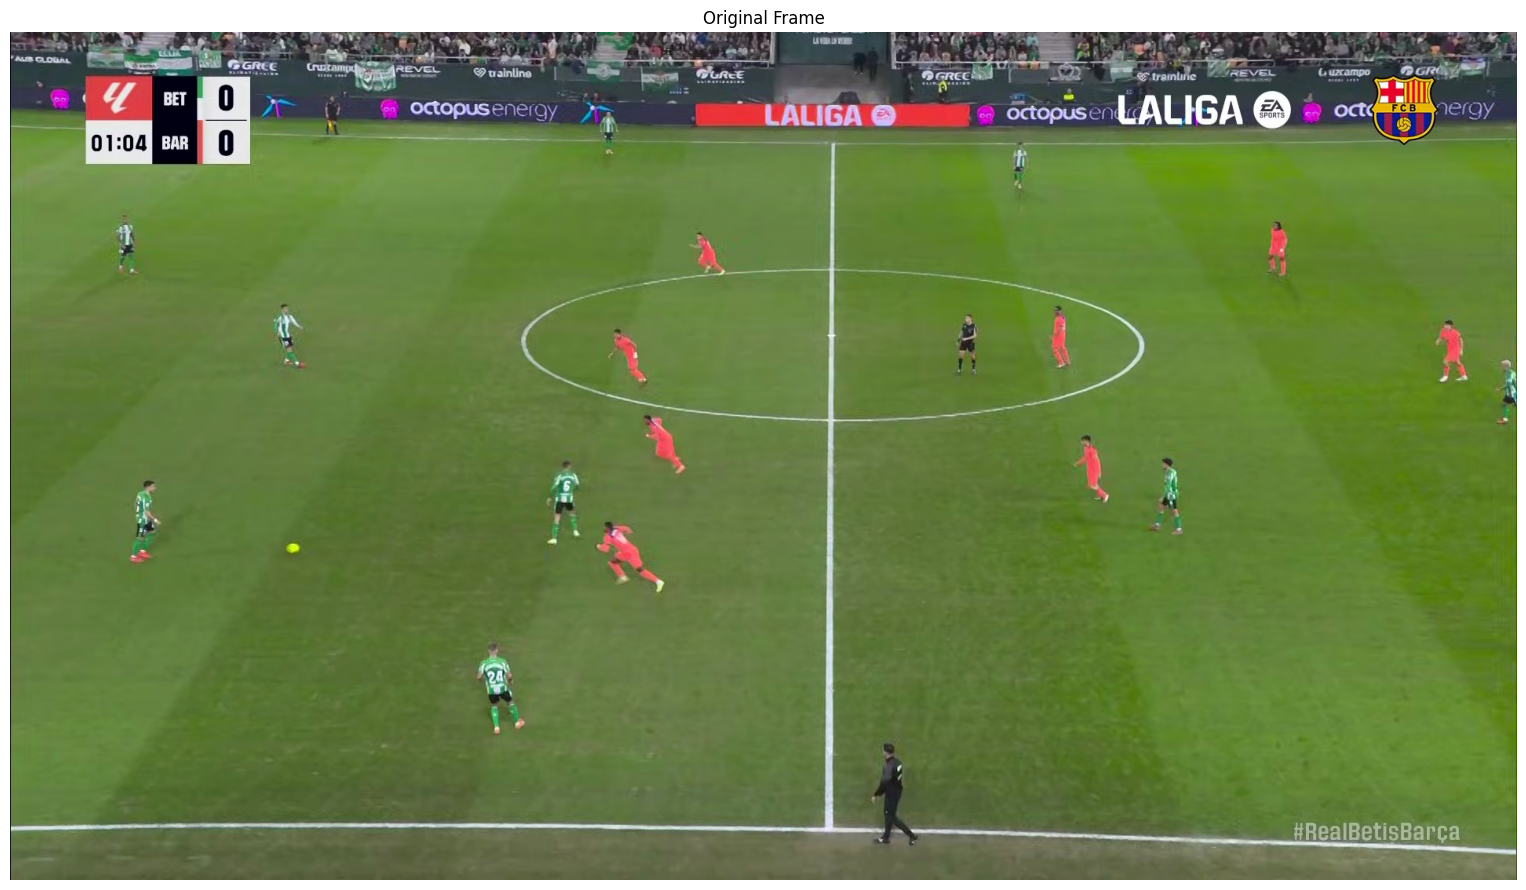

In [5]:
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Original Frame')
plt.axis('off')
plt.tight_layout()
plt.show()

### Run Pipeline

This runs the full pipeline on the single test frame.

In [6]:
result = pipeline.process_frame(frame, frame_idx=frame_num)

H = result['H']
H_info = result['H_info']
used_kpts = result['keypoints_used']
player_pitch_pts = result['player_pitch_pts']

print(f"Homography mode:   {H_info.get('mode', 'N/A')}")
print(f"Keypoints used:    {len(used_kpts)}")
print(f"Inliers:           {H_info.get('inliers', 0)} / {H_info.get('total_points', 0)}")
print(f"Players detected:  {len(player_pitch_pts)}")

if H is None:
    print("\n⚠️  Could not compute homography on this frame.")
else:
    print("\n✅ Homography computed successfully.")

NOTHING REMOVED
Homography mode:   keypoint-ransac
Keypoints used:    4
Inliers:           4 / 4
Players detected:  21

✅ Homography computed successfully.


## Output Visualizations

### 1. Annotated Frame (Keypoints + Segmentation Overlay)

The original frame with:
- **Yellow dots**: Keypoints used for homography (with labels)
- **Colored polygons**: Segmentation masks (deep analysis)

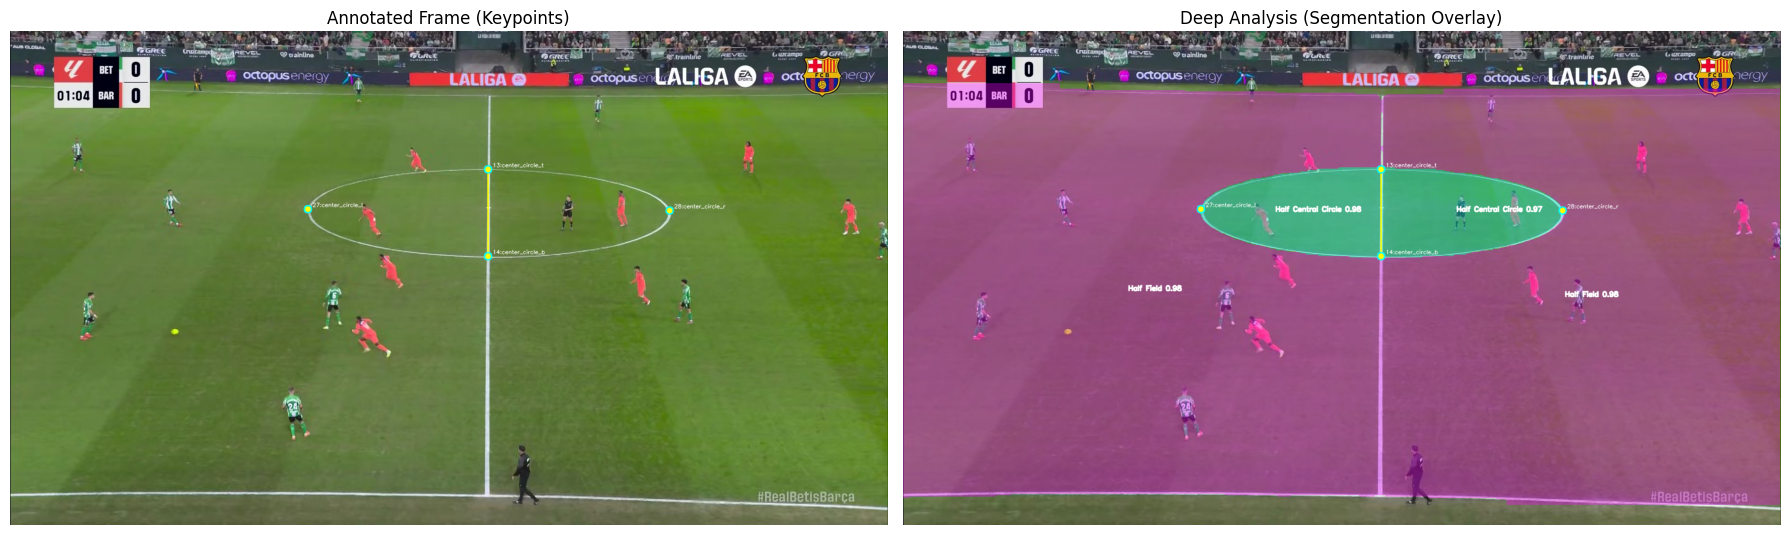

In [7]:
plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
annotated = result['annotated_frame']
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Annotated Frame (Keypoints)')
plt.axis('off')

plt.subplot(1, 2, 2)
deep_analysis = result['deep_analysis_frame']
plt.imshow(cv2.cvtColor(deep_analysis, cv2.COLOR_BGR2RGB))
plt.title('Deep Analysis (Segmentation Overlay)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Top-Down Pitch Canvas

Bird's-eye view of the pitch with players projected via the homography. Red dots show player positions.

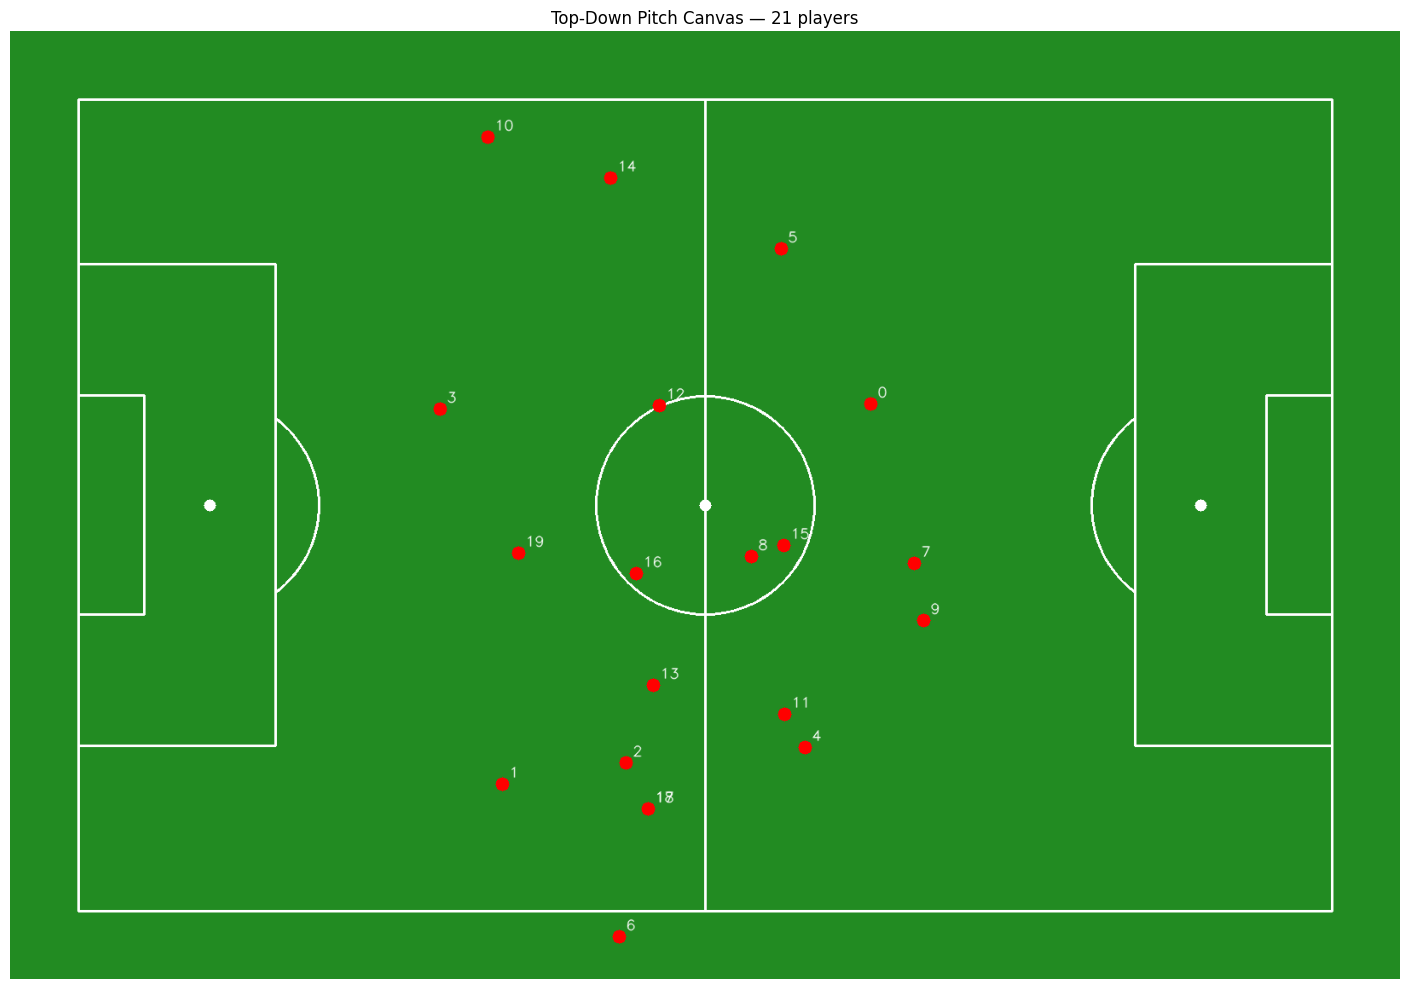

In [8]:
pitch_canvas = result['pitch_canvas']
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(pitch_canvas, cv2.COLOR_BGR2RGB))
plt.title(f'Top-Down Pitch Canvas — {len(player_pitch_pts)} players')
plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Keypoint Details

List all keypoints used in the homography computation.

In [9]:
print(f"{'ID':<4} {'Name':<30} {'Image (x,y)':<25} {'Pitch (x,y)':<20} {'Conf':<6}")
print('-' * 85)
for kp in used_kpts:
    img_pt = f"({kp['image_pt'][0]:.1f}, {kp['image_pt'][1]:.1f})"
    pitch_pt = f"({kp['pitch_pt'][0]:.2f}, {kp['pitch_pt'][1]:.2f})"
    print(f"{kp['kpt_id']:<4} {kp['name']:<30} {img_pt:<25} {pitch_pt:<20} {kp['confidence']:<6.1f}")

ID   Name                           Image (x,y)               Pitch (x,y)          Conf  
-------------------------------------------------------------------------------------
13   center_circle_top              (1045.4, 302.9)           (52.50, 24.85)       0.5   
14   center_circle_bottom           (1045.1, 492.5)           (52.50, 43.15)       0.6   
27   center_circle_left             (651.4, 389.9)            (43.35, 34.00)       0.4   
28   center_circle_right            (1442.3, 392.8)           (61.65, 34.00)       0.5   


## Process Full Video

Process the entire video and generate three output videos:
- `full_pitch_debug_map.mp4` — Top-down pitch view
- `annotated_video.mp4` — Original frame with keypoints
- `deep_analysis.mp4` — Original frame with segmentation overlay

In [10]:
# Process a limited number of frames for quick testing
FRAMES_TO_PROCESS = None # Set to None for all frames
START_FRAME = 0

print(f"Processing {FRAMES_TO_PROCESS or 'all'} frames starting from frame {START_FRAME}...")

for i, frame_result in enumerate(pipeline.process_video(
    source_video_path=SOURCE_VIDEO_PATH,
    output_dir=str(OUTPUT_DIR),
    start_frame=START_FRAME,
    max_frames=FRAMES_TO_PROCESS,
    process_every_n=1,
)):
    pass  # Processing happens in the generator

print("\nVideo processing complete!")

Processing all frames starting from frame 0...
Video: 25.0FPS, 1920x1080, 750 frames
Processing from frame 0, max_frames=None
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
  Frame 29: H=fallback-last, kpts=3, players=18
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING RE

## Summary

**Pipeline architecture**:
```
Frame → Keypoint Model → 29 keypoints (x, y, vis)
                            ↓ filter by confidence & visibility
                            ↓ map to pitch coordinates via PitchKeypointMapper
                            ↓ cv2.findHomography(RANSAC) → H matrix
                            ↓
Frame → Player Model → bboxes → bottom-center → perspectiveTransform(H) → pitch coords
                            ↓
Frame → Segmentation Model → masks → overlay on original frame (deep analysis)
```

**Key files**:
- `app/keypoint_service.py` — `PitchKeypointMapper` + `KeypointHomographyComputer`
- `app/keypoint_pipeline.py` — `KeypointPipeline` orchestrator
- `app/constants.py` — Configuration (KEYPOINT_CONF, KEYPOINT_MIN_CONF)